In [7]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import xgboost as xgb
import lightgbm as lgb

In [8]:

# ==========================================
# 2. Load Dataset
# ==========================================
df = pd.read_csv("diabetes.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())


Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Gluco

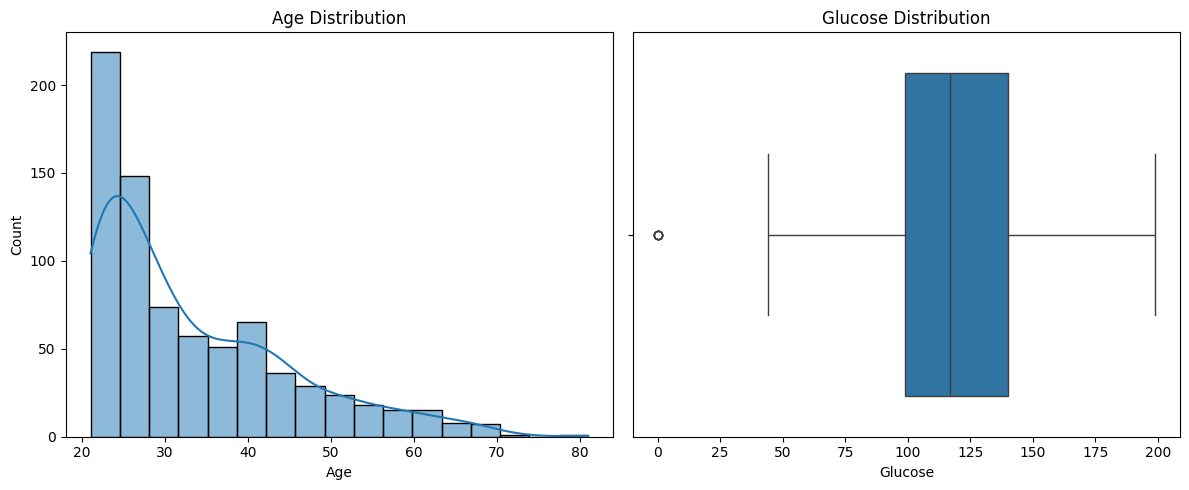

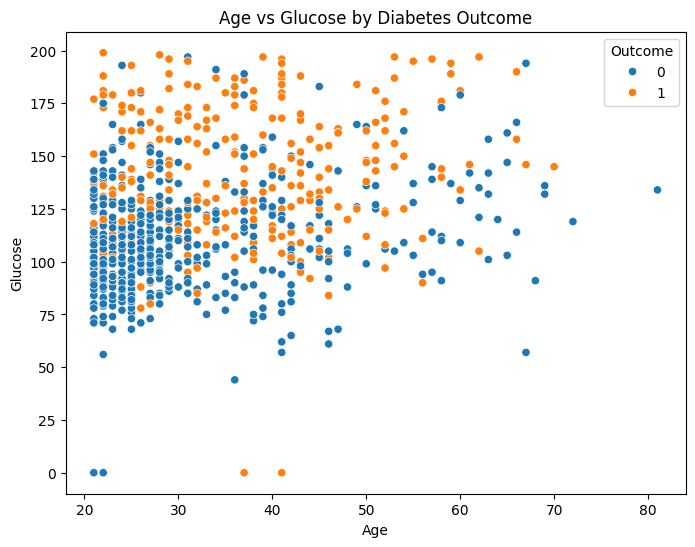

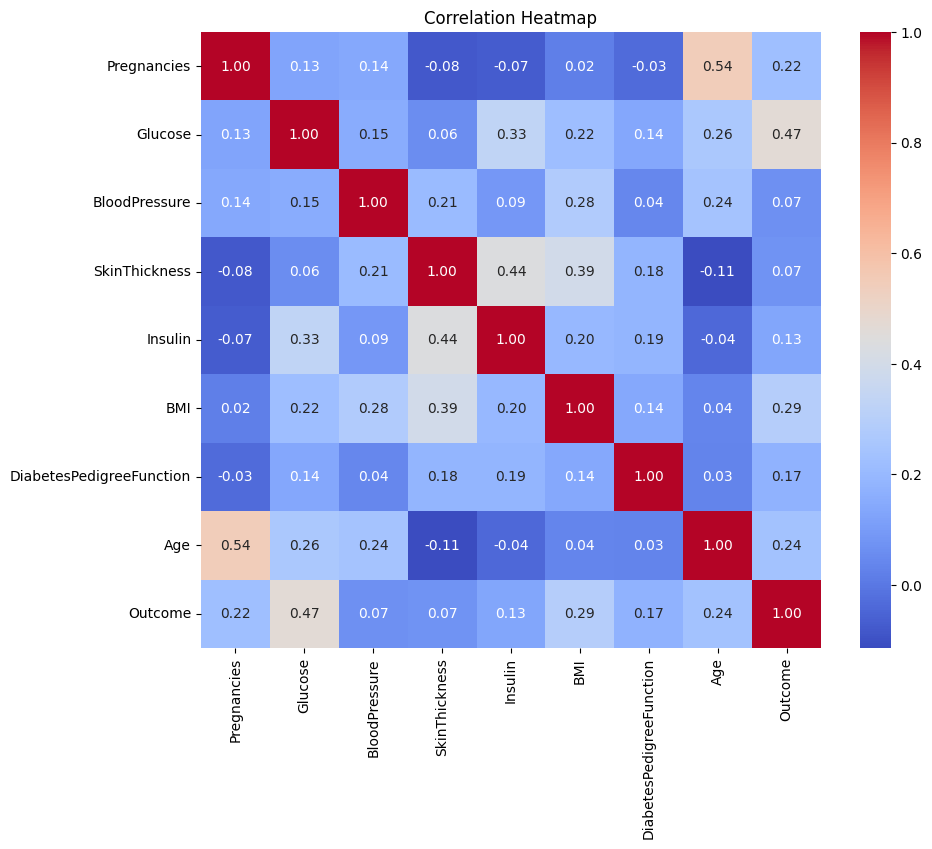

In [9]:
# ==========================================
# 3. EDA
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df['Glucose'])
plt.title("Glucose Distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df)
plt.title("Age vs Glucose by Diabetes Outcome")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# ==========================================
# 4. Data Preprocessing
# ==========================================

# Replace 0 values with median (biologically impossible zeros)
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())

In [11]:
# ==========================================
# 5. Train Test Split
# ==========================================
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# ==========================================
# 6. Cross-Validation Setup
# ==========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

In [13]:
# ==========================================
# 7. XGBoost with GridSearchCV
# ==========================================
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nTuning XGBoost...")
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_


Tuning XGBoost...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:11:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [14]:
# ==========================================
# 8. LightGBM with RandomizedSearchCV
# ==========================================
lgb_model = lgb.LGBMClassifier(random_state=42)

lgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'subsample': [0.8, 1.0]
}

lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_param_dist,
    n_iter=10,
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nTuning LightGBM...")
lgb_random.fit(X_train, y_train)

best_lgb = lgb_random.best_estimator_


Tuning LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [15]:
# ==========================================
# 9. Evaluation Function
# ==========================================
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    }


XGBoost Results:
Accuracy: 0.7337662337662337
Precision: 0.6444444444444445
Recall: 0.5370370370370371
F1 Score: 0.5858585858585859

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154


LightGBM Results:
Accuracy: 0.7662337662337663
Precision: 0.7045454545454546
Recall: 0.5740740740740741
F1 Score: 0.6326530612244898

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       100
           1       0.70      0.57      0.63        54

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154


--- Final Model Comparison ---

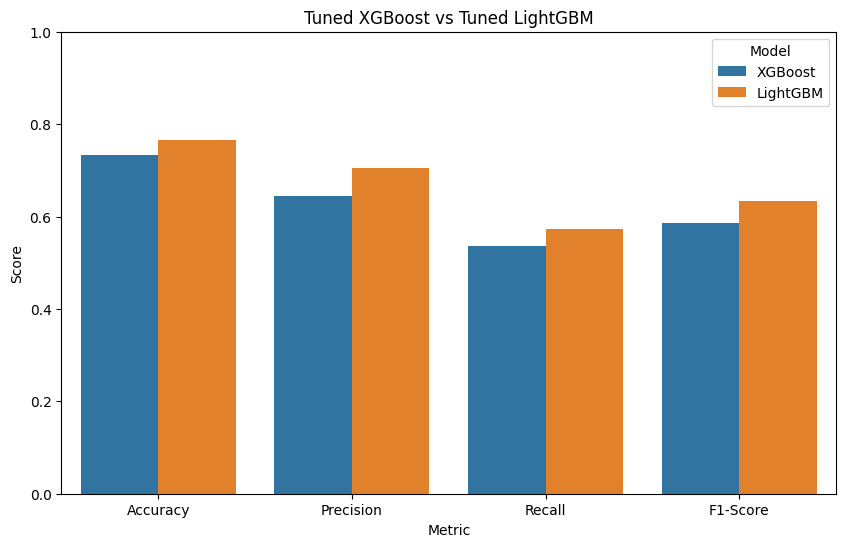

In [16]:
# ==========================================
# 10. Compare Models
# ==========================================
results = []
results.append(evaluate(best_xgb, X_test, y_test, "XGBoost"))
results.append(evaluate(best_lgb, X_test, y_test, "LightGBM"))

results_df = pd.DataFrame(results)
print("\n--- Final Model Comparison ---")
print(results_df)

# Visualization
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.ylim(0,1)
plt.title("Tuned XGBoost vs Tuned LightGBM")
plt.show()

In [17]:
# ==========================================
# 11. Best Parameters
# ==========================================
print("\nBest XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest LightGBM Parameters:")
print(lgb_random.best_params_)



Best XGBoost Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best LightGBM Parameters:
{'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}
